In [1]:
from datasets import load_dataset

In [2]:
cache_dir = "./data"

ds = load_dataset("lmms-lab/ChartQA", cache_dir=cache_dir)

In [3]:
split_name = "train" if "train" in ds else list(ds.keys())[0]
sample_ds = ds[split_name]

print(f"\nVizsgált split: {split_name}")
print("Feature-ök:", sample_ds.column_names)
print("Schema:", sample_ds.features)

for i in range(min(2, len(sample_ds))):
    row = sample_ds[i]
    print(f"\n[{i}] question: {row.get('question')}")
    print(f"[{i}] answer: {row.get('answer')}")
    img = row.get('image')
    if img is not None:
        print(f"[{i}] image type: {type(img).__name__}, size: {getattr(img, 'size', None)}")


Vizsgált split: test
Feature-ök: ['type', 'question', 'answer', 'image']
Schema: {'type': Value('string'), 'question': Value('string'), 'answer': Value('string'), 'image': Image(mode=None, decode=True)}

[0] question: How many food item is shown in the bar graph?
[0] answer: 14
[0] image type: PngImageFile, size: (850, 600)

[1] question: What is the difference in value between Lamb and Corn?
[1] answer: 0.57
[1] image type: PngImageFile, size: (850, 600)


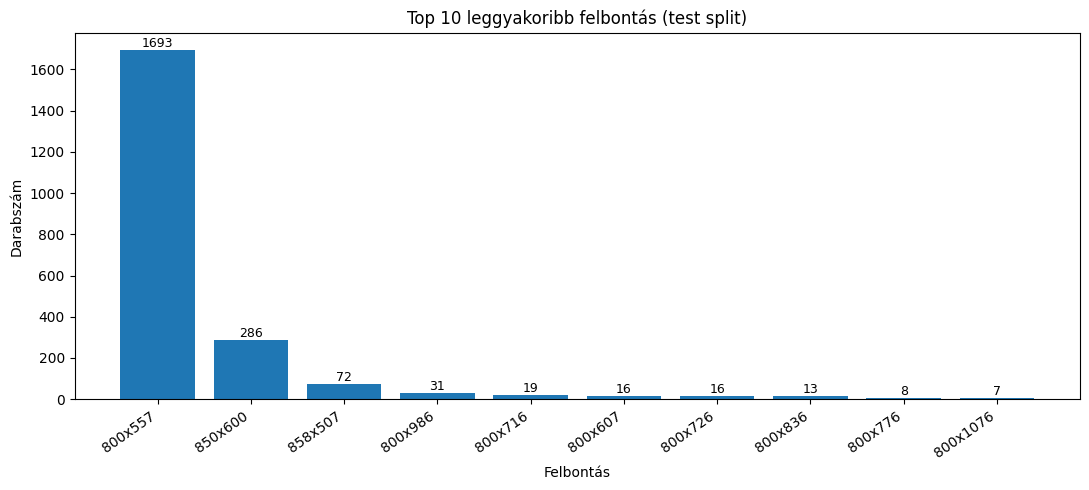

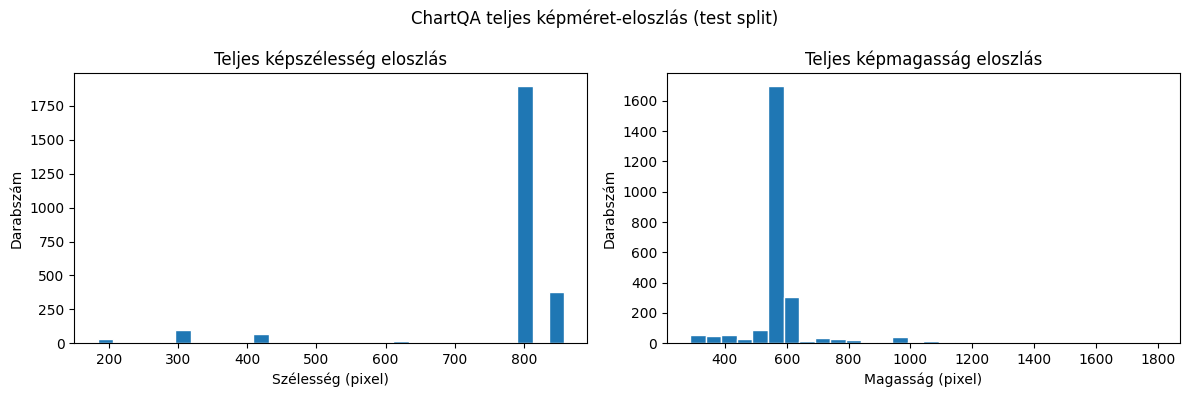

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

split_name = "train" if "train" in ds else list(ds.keys())[0]
split_ds = ds[split_name]

size_counter = Counter()
widths = []
heights = []

for row in split_ds:
    img = row.get("image")
    if img is None:
        continue
    w, h = img.size
    widths.append(w)
    heights.append(h)
    size_counter[(w, h)] += 1

total = sum(size_counter.values())

top10 = size_counter.most_common(10)

labels = [f"{w}x{h}" for (w, h), _ in top10]
counts = [cnt for _, cnt in top10]

plt.figure(figsize=(11, 5))
bars = plt.bar(labels, counts)
plt.title(f"Top 10 leggyakoribb felbontás ({split_name} split)")
plt.xlabel("Felbontás")
plt.ylabel("Darabszám")
plt.xticks(rotation=35, ha="right")

for bar, cnt in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(cnt),
        ha="center",
        va="bottom",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins_w = min(30, max(5, len(set(widths))))
bins_h = min(30, max(5, len(set(heights))))

axes[0].hist(widths, bins=bins_w, edgecolor="white")
axes[0].set_title("Teljes képszélesség eloszlás")
axes[0].set_xlabel("Szélesség (pixel)")
axes[0].set_ylabel("Darabszám")

axes[1].hist(heights, bins=bins_h, edgecolor="white")
axes[1].set_title("Teljes képmagasság eloszlás")
axes[1].set_xlabel("Magasság (pixel)")
axes[1].set_ylabel("Darabszám")

fig.suptitle(f"ChartQA teljes képméret-eloszlás ({split_name} split)")
plt.tight_layout()
plt.show()